# Description Ablation — Qwen3-VL-8B · 128 UCR Datasets

**Experiment:** `random_k1_desc_comparison_qwenvl8b_128`  
Model: `Qwen/Qwen3-VL-8B-Instruct` · random picking · k=1 · 5 seeds per dataset

| Condition | `use_label_desc` | Description source |
|---|---|---|
| **No Desc** | 0 | — |
| **With Desc** | 1 | `ucr_short_descriptions/<dataset>/description.txt` |

Evaluated on all **128 UCR datasets** with a `description.txt` in `ucr_short_descriptions/`.

In [1]:
import wandb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import operator, math, networkx
from pathlib import Path
from scipy.stats import wilcoxon, friedmanchisquare

if wandb.api.api_key is None:
    for folder in ["wandb_logger", "logger", ""]:
        token_path = Path(folder) / "token.txt"
        if token_path.exists():
            wandb.login(key=token_path.read_text().strip())
            break

ENTITY  = "aviramom-"
PROJECT = "multits"

EXP_ID = "random_k1_desc_comparison_qwenvl8b_128"

COND_NO   = "8B · No Desc"
COND_WITH = "8B · With Desc"
CONDITIONS = [COND_NO, COND_WITH]

N_SEEDS = 5   # seeds 0–4

api = wandb.Api(timeout=60)
print(f"Connected to {ENTITY}/{PROJECT}")
print(f"  Exp ID : {EXP_ID}")

/home/aviramom/.conda/envs/multits/lib/python3.10/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.5.0) or chardet (7.0.1)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(
wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.


Connected to aviramom-/multits
  Exp ID : random_k1_desc_comparison_qwenvl8b_128


## 1 · Load Data from W&B

Runs are fetched from W&B and cached locally. Set `FORCE_REFRESH = True` when new runs finish.

In [2]:
from tqdm.auto import tqdm

CONFIG_KEYS = ["task_id", "method", "num_samples", "exp_id", "input_mode",
               "num_shots", "random_seed", "picking_strategy", "use_label_desc"]
METRIC_KEYS = ["final_accuracy", "final_balanced_accuracy", "final_num_of_classes",
               "total_test_size", "flawed_count", "flawed_percentage"]

CACHE_PATH    = Path("cache_desc_comparison_qwenvl8b_128.parquet")
FORCE_REFRESH = False   # set True when new runs finish

def get_val(cfg, summary, key):
    return summary.get(key, cfg.get(key))

def fetch_exp(exp_id, cache_path):
    if cache_path.exists() and not FORCE_REFRESH:
        df = pd.read_parquet(cache_path)
        print(f"Loaded {len(df)} rows from cache ({cache_path})")
        return df
    all_runs = list(api.runs(path=f"{ENTITY}/{PROJECT}", per_page=1000))
    rows = []
    for run in tqdm(all_runs, desc=f"Processing {exp_id}"):
        summary = {k: v for k, v in (run.summary or {}).items() if not k.startswith("_")}
        cfg     = run.config or {}
        if get_val(cfg, summary, "exp_id") != exp_id:
            continue
        row = {"run_id": run.id, "run_name": run.name, "state": run.state}
        for k in CONFIG_KEYS:
            row[k] = get_val(cfg, summary, k)
        for k in METRIC_KEYS:
            row[k] = get_val(cfg, summary, k)
        rows.append(row)
    df = pd.DataFrame(rows)
    for col in METRIC_KEYS:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")
    df.to_parquet(cache_path)
    print(f"Cached {len(df)} rows → {cache_path}")
    return df

df_raw = fetch_exp(EXP_ID, CACHE_PATH)
df_raw["condition"] = (
    pd.to_numeric(df_raw["use_label_desc"], errors="coerce")
    .fillna(0).astype(int)
    .map({0: COND_NO, 1: COND_WITH})
)
df_raw["task"] = df_raw["task_id"].str.replace("icl_ucr_", "", regex=False)

print(f"\n{'─'*50}")
print(f"Total runs loaded : {len(df_raw)}")
print(f"Finished          : {(df_raw['state'] == 'finished').sum()}")
print(f"Conditions        : {df_raw['condition'].value_counts().to_dict()}")

Processing random_k1_desc_comparison_qwenvl8b_128:   0%|          | 0/1861 [00:00<?, ?it/s]

Cached 1280 rows → cache_desc_comparison_qwenvl8b_128.parquet

──────────────────────────────────────────────────
Total runs loaded : 1280
Finished          : 1280
Conditions        : {'8B · No Desc': 640, '8B · With Desc': 640}


In [3]:
import sys, os
sys.path.insert(0, "." if os.path.exists("data_provider") else "..")

# Build the set of 128 tasks from ucr_short_descriptions/
short_desc_dir = Path("ucr_short_descriptions" if os.path.exists("ucr_short_descriptions") else "../ucr_short_descriptions")
SHORT_DESC_TASKS = {d.name for d in short_desc_dir.iterdir() if d.is_dir() and (d / "description.txt").exists()} if short_desc_dir.exists() else set()

finished = df_raw[(df_raw["state"] == "finished") & (df_raw["task"].isin(SHORT_DESC_TASKS))].copy() if SHORT_DESC_TASKS else df_raw[df_raw["state"] == "finished"].copy()
tasks    = sorted(finished["task"].unique())

print(f"Datasets with short_description files : {len(SHORT_DESC_TASKS)}")
print(f"Datasets present in results           : {len(tasks)}")
if SHORT_DESC_TASKS:
    missing = SHORT_DESC_TASKS - set(tasks)
    if missing:
        print(f"Missing from results ({len(missing)}): {sorted(missing)}")

print(f"\nTotal finished runs : {len(finished)}")
for cond in CONDITIONS:
    sub = finished[finished["condition"] == cond]
    print(f"  {cond:20s}: {len(sub)} runs, {sub['task'].nunique()} tasks")

Datasets with short_description files : 128
Datasets present in results           : 128

Total finished runs : 1280
  8B · No Desc        : 640 runs, 128 tasks
  8B · With Desc      : 640 runs, 128 tasks


## 2 · Results

Balanced accuracy (average per-class recall) — mean ± std across 5 seeds.

In [4]:
import re

# ── UCR reference data ────────────────────────────────────────────────────────
ref_path = Path("icl_data/DataSummary.csv" if os.path.exists("icl_data/DataSummary.csv") else "../icl_data/DataSummary.csv")
try:
    summary_raw = pd.read_csv(ref_path)
    summary_raw.columns = summary_raw.columns.str.strip()
    def _parse_err(val):
        m = re.match(r"\s*([\d.]+)", str(val))
        return float(m.group(1)) if m else np.nan
    summary_raw["DTW_acc"]         = 1.0 - summary_raw["DTW (w=100)"].apply(_parse_err)
    summary_raw["num_classes"]     = pd.to_numeric(summary_raw["Class"], errors="coerce")
    summary_raw["default_bal_acc"] = 1.0 / summary_raw["num_classes"]
    ucr_ref = summary_raw.set_index("Name")[["DTW_acc", "default_bal_acc"]]
    HAS_REF = True
except FileNotFoundError:
    ucr_ref, HAS_REF = pd.DataFrame(), False
    print("UCR reference CSV not found — reference columns omitted.")

# ── Pivot ─────────────────────────────────────────────────────────────────────
mean_p = finished.pivot_table(index="task", columns="condition",
                               values="final_balanced_accuracy", aggfunc="mean")
std_p  = finished.pivot_table(index="task", columns="condition",
                               values="final_balanced_accuracy", aggfunc="std")

cols   = [c for c in CONDITIONS if c in mean_p.columns]
mean_p = mean_p[cols].reindex(tasks)
std_p  = std_p[cols].reindex(tasks)
mean_p.columns.name = std_p.columns.name = ""

REF_COLS = []
if HAS_REF:
    mean_p["DTW (w=100)"]  = [ucr_ref.loc[t, "DTW_acc"]         if t in ucr_ref.index else np.nan for t in tasks]
    mean_p["Default Rate"] = [ucr_ref.loc[t, "default_bal_acc"] if t in ucr_ref.index else np.nan for t in tasks]
    REF_COLS = ["DTW (w=100)", "Default Rate"]

mean_p["Δ (with−no)"] = mean_p[COND_WITH] - mean_p[COND_NO]
EXTRA_COLS = REF_COLS + ["Δ (with−no)"]

macro = mean_p.mean(axis=0); macro.name = "Macro Avg"
mean_p = pd.concat([mean_p, macro.to_frame().T])
mean_p.index.name = "Task"

fmt = mean_p.copy().astype(object)
for col in mean_p.columns:
    for idx in mean_p.index:
        m_val = mean_p.loc[idx, col]
        if col not in EXTRA_COLS and idx != "Macro Avg" and col in std_p.columns and idx in std_p.index:
            s_val = std_p.loc[idx, col]
            fmt.loc[idx, col] = f"{m_val:.3f} ± {s_val:.3f}" if pd.notna(m_val) else "—"
        else:
            fmt.loc[idx, col] = f"{m_val:.3f}" if pd.notna(m_val) else "—"

print("BALANCED ACCURACY  (mean ± std over seeds)")
display(
    fmt.style
    .set_caption("Balanced Accuracy — 8B · No Desc vs With Desc · 128 UCR datasets")
    .set_table_styles([{"selector": "th", "props": [("text-align", "center"), ("font-weight", "bold")]}])
)

BALANCED ACCURACY  (mean ± std over seeds)


,8B · No Desc,8B · With Desc,DTW (w=100),Default Rate,Δ (with−no)
Task,,,,,
ACSF1,0.240 ± 0.035,0.230 ± 0.037,0.640,0.100,-0.010
Adiac,0.086 ± 0.021,0.072 ± 0.023,0.604,0.027,-0.015
AllGestureWiimoteX,0.188 ± 0.040,0.179 ± 0.034,0.716,0.100,-0.008
AllGestureWiimoteY,0.227 ± 0.034,0.201 ± 0.029,0.729,0.100,-0.025
AllGestureWiimoteZ,0.212 ± 0.014,0.193 ± 0.010,0.643,0.100,-0.019
ArrowHead,0.424 ± 0.075,0.394 ± 0.072,0.703,0.333,-0.030
BME,0.576 ± 0.079,0.748 ± 0.100,0.900,0.333,0.172
Beef,0.280 ± 0.051,0.293 ± 0.060,0.633,0.200,0.013
BeetleFly,0.630 ± 0.076,0.580 ± 0.110,0.700,0.500,-0.050


### Balanced Accuracy Heatmap

In [5]:
tbl        = mean_p.drop(index="Macro Avg", errors="ignore")
model_cols = [c for c in cols if c in tbl.columns]
delta_col  = "Δ (with−no)"

display(
    tbl[model_cols].style
    .background_gradient(cmap="RdYlGn", axis=None, vmin=0, vmax=1)
    .format("{:.3f}", na_rep="—")
    .set_caption("Balanced Accuracy — No Desc vs With Desc")
)

if delta_col in tbl.columns:
    vabs = tbl[delta_col].abs().max()
    display(
        tbl[[delta_col]].style
        .background_gradient(cmap="RdBu", axis=None, vmin=-vabs, vmax=vabs)
        .format("{:.3f}", na_rep="—")
        .set_caption("Δ (With Desc − No Desc)")
    )

if HAS_REF and REF_COLS:
    display(tbl[REF_COLS].style.format("{:.3f}", na_rep="—").set_caption("UCR reference — Balanced Accuracy"))

,8B · No Desc,8B · With Desc
Task,,
ACSF1,0.240,0.230
Adiac,0.086,0.072
AllGestureWiimoteX,0.188,0.179
AllGestureWiimoteY,0.227,0.201
AllGestureWiimoteZ,0.212,0.193
ArrowHead,0.424,0.394
BME,0.576,0.748
Beef,0.280,0.293
BeetleFly,0.630,0.580


,Δ (with−no)
Task,
ACSF1,-0.010
Adiac,-0.015
AllGestureWiimoteX,-0.008
AllGestureWiimoteY,-0.025
AllGestureWiimoteZ,-0.019
ArrowHead,-0.030
BME,0.172
Beef,0.013
BeetleFly,-0.050


,DTW (w=100),Default Rate
Task,,
ACSF1,0.640,0.100
Adiac,0.604,0.027
AllGestureWiimoteX,0.716,0.100
AllGestureWiimoteY,0.729,0.100
AllGestureWiimoteZ,0.643,0.100
ArrowHead,0.703,0.333
BME,0.900,0.333
Beef,0.633,0.200
BeetleFly,0.700,0.500


### Completed Runs per (Task, Condition) — target: 5

In [6]:
count_tbl = finished.pivot_table(
    index="task", columns="condition",
    values="final_balanced_accuracy", aggfunc="count"
).fillna(0).astype(int)
count_tbl = count_tbl[[c for c in CONDITIONS if c in count_tbl.columns]]
count_tbl.index.name = "Task"; count_tbl.columns.name = ""

total   = N_SEEDS
incomplete = count_tbl[(count_tbl < total).any(axis=1)]
print(f"Tasks with incomplete runs (< {total} seeds): {len(incomplete)}")
if len(incomplete):
    display(incomplete)

display(
    count_tbl.style
    .background_gradient(cmap="YlGn", axis=None, vmin=0, vmax=total)
    .set_caption(f"Completed runs per (task, condition) — target: {total}")
)

Tasks with incomplete runs (< 5 seeds): 0


,8B · No Desc,8B · With Desc
Task,,
ACSF1,5,5
Adiac,5,5
AllGestureWiimoteX,5,5
AllGestureWiimoteY,5,5
AllGestureWiimoteZ,5,5
ArrowHead,5,5
BME,5,5
Beef,5,5
BeetleFly,5,5


## 3 · Per-Dataset Delta

Δ = **With Description** − **No Description**.
Green = description helps, red = description hurts.

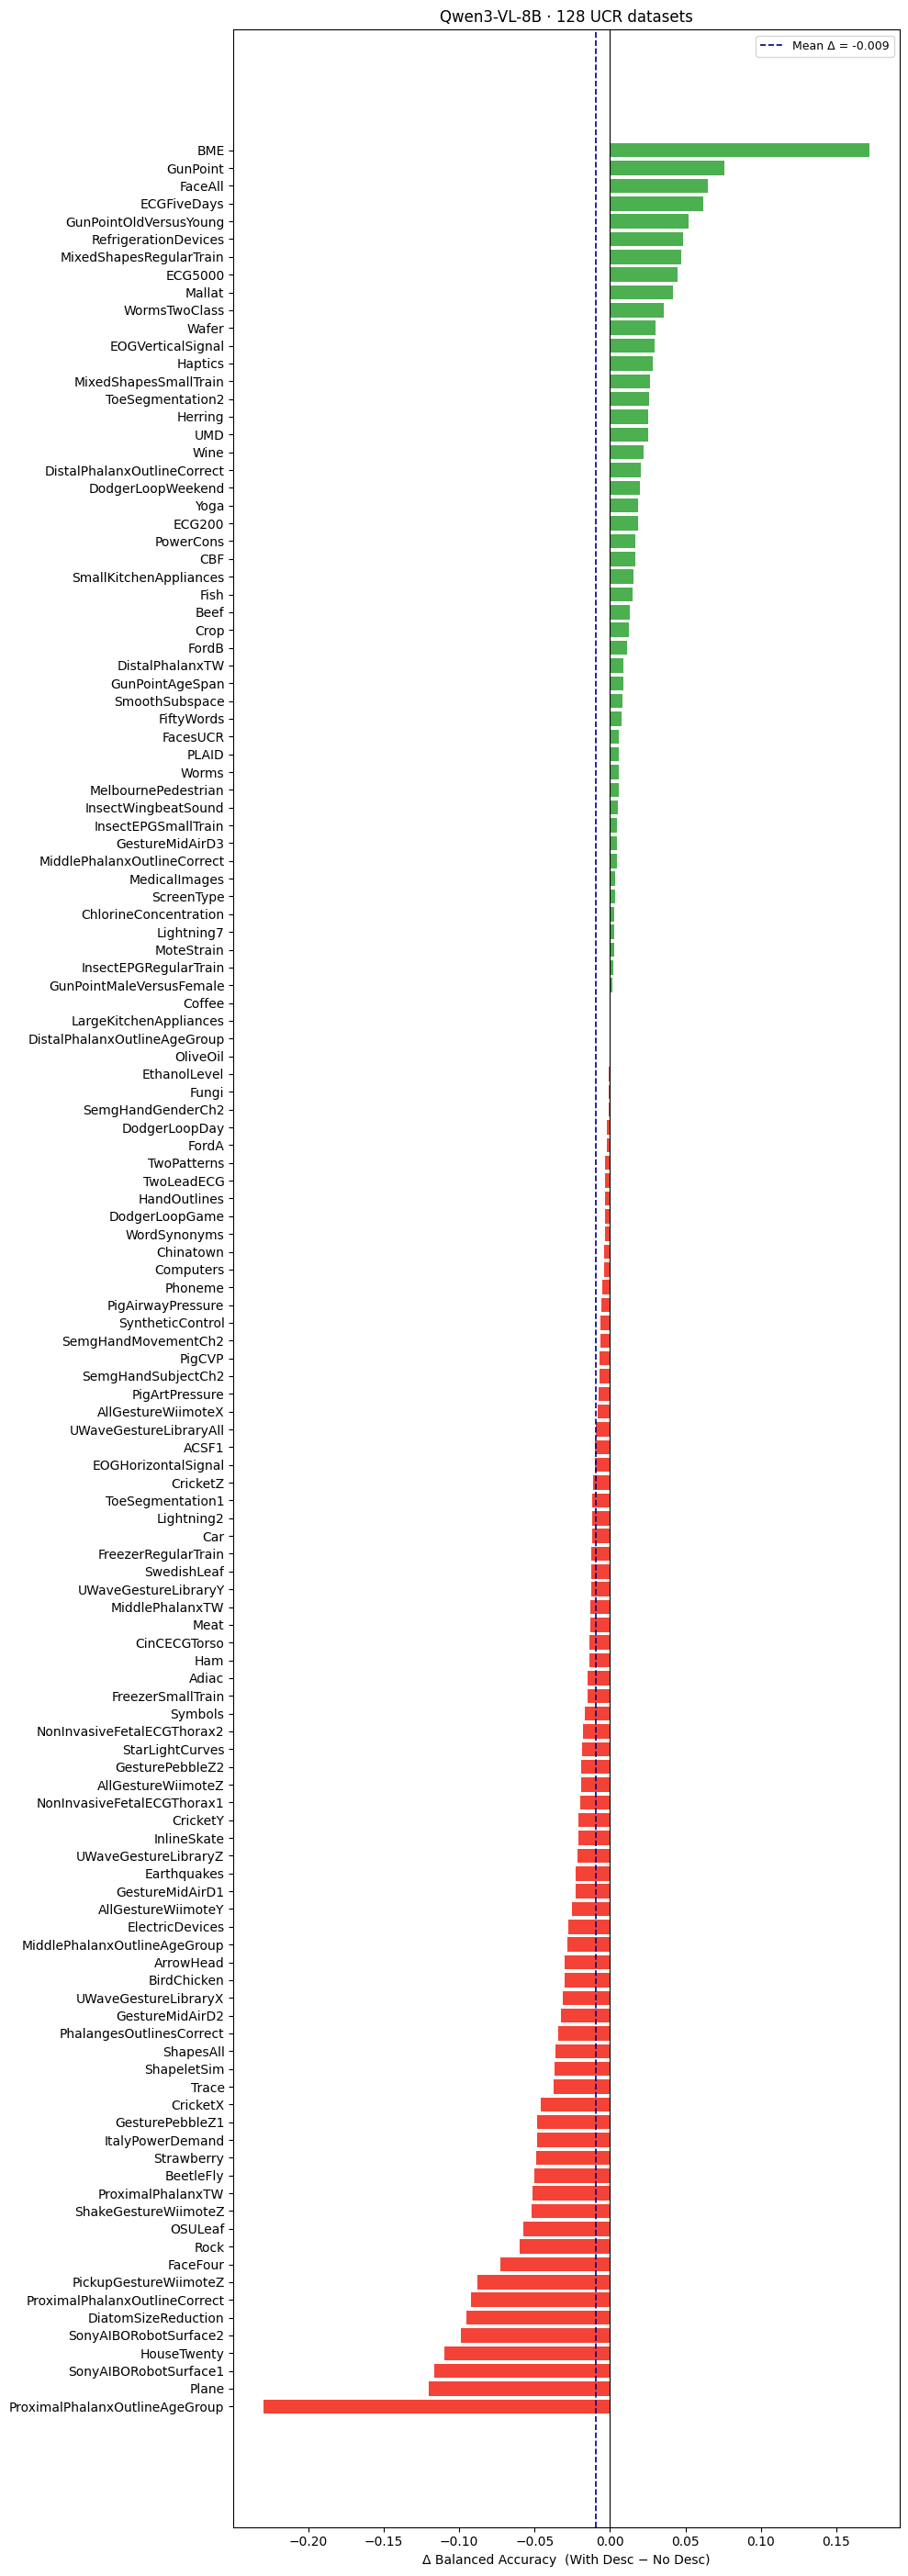

Mean Δ            : -0.0094
Datasets improved : 51 / 128
Datasets hurt     : 76 / 128
Datasets tied     : 1 / 128


In [7]:
tbl   = mean_p.drop(index="Macro Avg", errors="ignore")
delta = (tbl[COND_WITH] - tbl[COND_NO]).dropna().sort_values(ascending=False)

colors = ["#4CAF50" if v >= 0 else "#F44336" for v in delta]
fig, ax = plt.subplots(figsize=(10, max(4, len(delta) * 0.22)))
ax.barh(delta.index[::-1], delta.values[::-1], color=colors[::-1])
ax.axvline(0, color="black", linewidth=0.8)
mean_d = delta.mean()
ax.axvline(mean_d, color="navy", linewidth=1.2, linestyle="--", label=f"Mean Δ = {mean_d:+.3f}")
ax.set_xlabel("Δ Balanced Accuracy  (With Desc − No Desc)")
ax.set_title("Qwen3-VL-8B · 128 UCR datasets")
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

print(f"Mean Δ            : {mean_d:+.4f}")
print(f"Datasets improved : {(delta > 0).sum()} / {len(delta)}")
print(f"Datasets hurt     : {(delta < 0).sum()} / {len(delta)}")
print(f"Datasets tied     : {(delta == 0).sum()} / {len(delta)}")

### Scatter: No Description vs With Description

Points above the diagonal → description helps on that dataset.

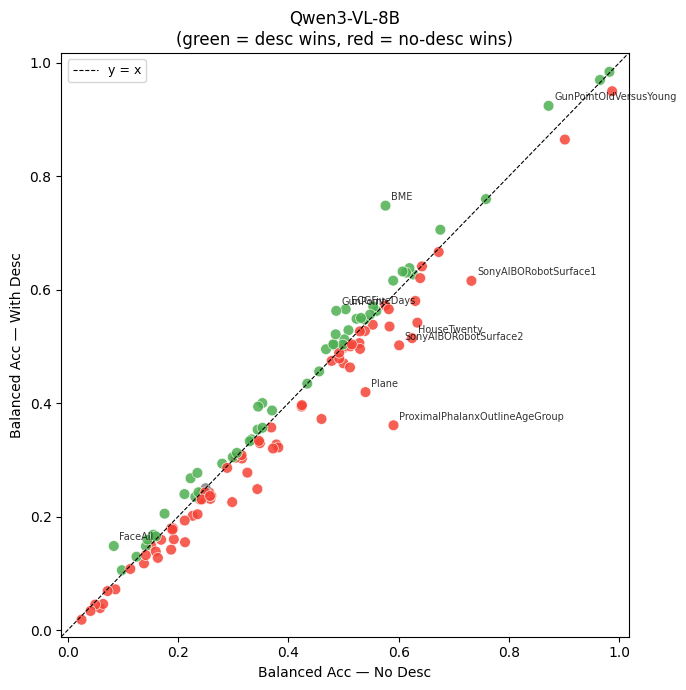

In [8]:
tbl    = mean_p.drop(index="Macro Avg", errors="ignore")
paired = tbl[[COND_NO, COND_WITH]].dropna()
x, y   = paired[COND_NO].values, paired[COND_WITH].values
colors = ["#4CAF50" if yi > xi else "#F44336" if yi < xi else "gray" for xi, yi in zip(x, y)]

fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(x, y, c=colors, s=60, alpha=0.85, edgecolors="white", linewidths=0.5)
lim = [min(x.min(), y.min()) - 0.03, max(x.max(), y.max()) + 0.03]
ax.plot(lim, lim, "k--", linewidth=0.8, label="y = x")
ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xlabel("Balanced Acc — No Desc")
ax.set_ylabel("Balanced Acc — With Desc")
ax.set_title("Qwen3-VL-8B\n(green = desc wins, red = no-desc wins)")
ax.legend(fontsize=9)
delta_arr = y - x
for i in list(np.argsort(delta_arr)[-5:][::-1]) + list(np.argsort(delta_arr)[:5]):
    ax.annotate(paired.index[i], (x[i], y[i]), fontsize=7, alpha=0.8,
                xytext=(4, 4), textcoords="offset points")
plt.tight_layout(); plt.show()

## 3.5 · Delta vs Number of Classes

Does description help more on harder (many-class) tasks?

,Num Classes,Δ (with−no)
Task,,
Chinatown,2,-0.004
Coffee,2,+0.001
BirdChicken,2,-0.030
BeetleFly,2,-0.050
DodgerLoopWeekend,2,+0.020
DodgerLoopGame,2,-0.003
DistalPhalanxOutlineCorrect,2,+0.020
Computers,2,-0.004
ECGFiveDays,2,+0.062



Spearman ρ (Num Classes ↔ Δ): ρ = -0.133,  p = 0.1359  n.s.


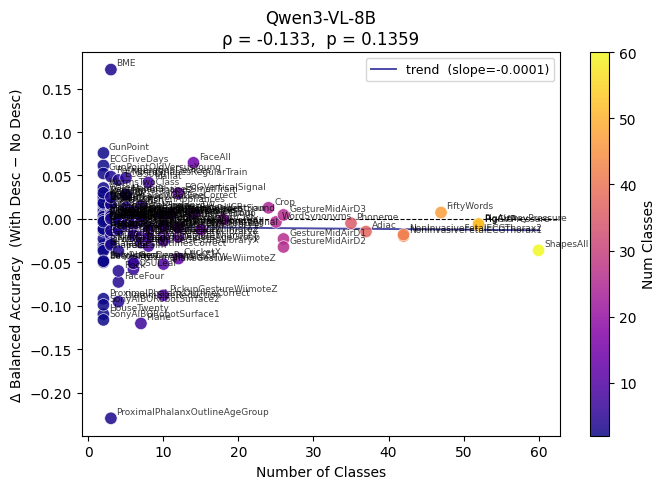

In [9]:
from scipy.stats import spearmanr

tbl = mean_p.drop(index="Macro Avg", errors="ignore").copy()
n_classes = (
    finished.groupby("task")["final_num_of_classes"]
    .median().round().dropna().astype(int)
)
tbl["Num Classes"]  = n_classes
tbl["Δ (with−no)"] = mean_p.drop(index="Macro Avg", errors="ignore")["Δ (with−no)"]

tbl_show = tbl[["Num Classes", "Δ (with−no)"]].dropna().sort_values("Num Classes")
vabs     = tbl_show["Δ (with−no)"].abs().max()

display(
    tbl_show.style
    .format({"Num Classes": "{:.0f}", "Δ (with−no)": "{:+.3f}"})
    .background_gradient(cmap="RdBu",  axis=None, subset=["Δ (with−no)"],  vmin=-vabs, vmax=vabs)
    .background_gradient(cmap="Blues", axis=0,    subset=["Num Classes"])
    .set_caption("Δ Balanced Accuracy (With Desc − No Desc) per task, sorted by class count")
)

paired = tbl_show.dropna()
rho, p_val = spearmanr(paired["Num Classes"], paired["Δ (with−no)"])
sig_str = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else "n.s."
print(f"\nSpearman ρ (Num Classes ↔ Δ): ρ = {rho:+.3f},  p = {p_val:.4f}  {sig_str}")

fig, ax = plt.subplots(figsize=(7, 5))
x_c, y_d = paired["Num Classes"].values, paired["Δ (with−no)"].values
sc = ax.scatter(x_c, y_d, c=x_c, cmap="plasma", s=80, alpha=0.85,
                edgecolors="white", linewidths=0.5, zorder=3)
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
if len(x_c) > 2:
    z = np.polyfit(x_c, y_d, 1)
    xfit = np.linspace(x_c.min(), x_c.max(), 100)
    ax.plot(xfit, np.polyval(z, xfit), color="navy", linewidth=1.4, alpha=0.7,
            label=f"trend  (slope={z[0]:+.4f})")
ax.set_xlabel("Number of Classes")
ax.set_ylabel("Δ Balanced Accuracy  (With Desc − No Desc)")
ax.set_title(f"Qwen3-VL-8B\nρ = {rho:+.3f},  p = {p_val:.4f}")
ax.legend(fontsize=9)
for i, task in enumerate(paired.index):
    ax.annotate(task, (x_c[i], y_d[i]), fontsize=6.5, alpha=0.75,
                xytext=(4, 3), textcoords="offset points")
plt.colorbar(sc, ax=ax, label="Num Classes")
plt.tight_layout(); plt.show()

## 4 · Statistical Test — Wilcoxon Signed-Rank

Paired test: is **With Description** significantly different from **No Description**?

In [10]:
tbl = mean_p.drop(index="Macro Avg", errors="ignore")

def sig(p):
    return '*** (p<0.001)' if p < 0.001 else '** (p<0.01)' if p < 0.01 else '* (p<0.05)' if p < 0.05 else 'n.s.'

paired  = tbl[[COND_NO, COND_WITH]].dropna()
a_vals  = paired[COND_NO].values
b_vals  = paired[COND_WITH].values

stat_2, p_2 = wilcoxon(b_vals, a_vals, zero_method="pratt", alternative="two-sided")
stat_g, p_g = wilcoxon(b_vals, a_vals, zero_method="pratt", alternative="greater")
stat_l, p_l = wilcoxon(b_vals, a_vals, zero_method="pratt", alternative="less")

print(f"{'─'*50}")
print(f"Qwen3-VL-8B  ·  128 UCR datasets")
print(f"  Paired datasets    : {len(paired)}")
print(f"  Mean No Desc       : {a_vals.mean():.4f}")
print(f"  Mean With Desc     : {b_vals.mean():.4f}")
print(f"  Mean Δ (with − no) : {(b_vals - a_vals).mean():+.4f}")
print(f"  Wilcoxon two-sided : stat={stat_2:.1f},  p={p_2:.4f}  {sig(p_2)}")
print(f"  Wilcoxon greater   : stat={stat_g:.1f},  p={p_g:.4f}  {sig(p_g)}")
print(f"  Wilcoxon less      : stat={stat_l:.1f},  p={p_l:.4f}  {sig(p_l)}")

──────────────────────────────────────────────────
Qwen3-VL-8B  ·  128 UCR datasets
  Paired datasets    : 128
  Mean No Desc       : 0.3931
  Mean With Desc     : 0.3837
  Mean Δ (with − no) : -0.0094
  Wilcoxon two-sided : stat=3004.5,  p=0.0076  ** (p<0.01)
  Wilcoxon greater   : stat=3004.5,  p=0.9962  n.s.
  Wilcoxon less      : stat=3004.5,  p=0.0038  ** (p<0.01)


## 5 · Results by Dataset Category

Grouped mean Δ and accuracy by broad dataset type.

Category-level summary:


,8B · No Desc mean,8B · No Desc count,8B · With Desc mean,8B · With Desc count,Δ (with−no) mean,Δ (with−no) count
Category,,,,,,
ECG/Medical,0.231,11.000,0.235,11.000,0.004,11.000
Image/Shape,0.301,17.000,0.287,17.000,-0.014,17.000
Motion/HAR,0.347,26.000,0.334,26.000,-0.012,26.000
Other,0.408,30.000,0.392,30.000,-0.016,30.000
Sensor/Device,0.498,27.000,0.486,27.000,-0.012,27.000
Simulated,0.536,8.000,0.563,8.000,0.027,8.000
Spectrographic,0.408,9.000,0.397,9.000,-0.011,9.000


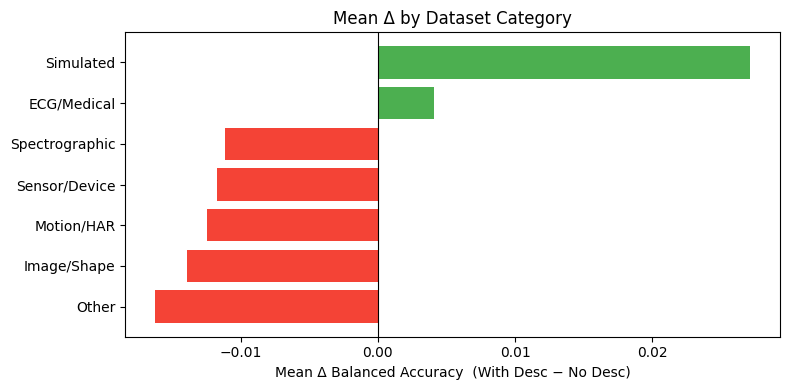

In [11]:
CATEGORY_MAP = {
    # Image / Shape
    "ArrowHead":"Image/Shape", "Fish":"Image/Shape", "Yoga":"Image/Shape", "Crop":"Image/Shape",
    "SwedishLeaf":"Image/Shape", "DiatomSizeReduction":"Image/Shape", "FaceAll":"Image/Shape",
    "FaceFour":"Image/Shape", "FacesUCR":"Image/Shape", "FiftyWords":"Image/Shape",
    "HandOutlines":"Image/Shape", "MedicalImages":"Image/Shape", "OSULeaf":"Image/Shape",
    "Symbols":"Image/Shape", "ShapesAll":"Image/Shape", "Beef":"Spectrographic",
    "WordSynonyms":"Image/Shape", "ShapeletSim":"Image/Shape",
    # ECG / Medical
    "ECG200":"ECG/Medical", "ECG5000":"ECG/Medical", "ECGFiveDays":"ECG/Medical",
    "TwoLeadECG":"ECG/Medical", "Phoneme":"ECG/Medical",
    "NonInvasiveFetalECGThorax1":"ECG/Medical", "NonInvasiveFetalECGThorax2":"ECG/Medical",
    "CinCECGTorso":"ECG/Medical", "PigAirwayPressure":"ECG/Medical",
    "PigArtPressure":"ECG/Medical", "PigCVP":"ECG/Medical",
    # Motion / HAR
    "CricketX":"Motion/HAR", "CricketY":"Motion/HAR", "CricketZ":"Motion/HAR",
    "GunPoint":"Motion/HAR", "GunPointAgeSpan":"Motion/HAR",
    "GunPointMaleVersusFemale":"Motion/HAR", "GunPointOldVersusYoung":"Motion/HAR",
    "UWaveGestureLibraryAll":"Motion/HAR", "UWaveGestureLibraryX":"Motion/HAR",
    "UWaveGestureLibraryY":"Motion/HAR", "UWaveGestureLibraryZ":"Motion/HAR",
    "AllGestureWiimoteX":"Motion/HAR", "AllGestureWiimoteY":"Motion/HAR",
    "AllGestureWiimoteZ":"Motion/HAR", "GestureMidAirD1":"Motion/HAR",
    "GestureMidAirD2":"Motion/HAR", "GestureMidAirD3":"Motion/HAR",
    "GesturePebbleZ1":"Motion/HAR", "GesturePebbleZ2":"Motion/HAR",
    "PickupGestureWiimoteZ":"Motion/HAR", "ShakeGestureWiimoteZ":"Motion/HAR",
    "ToeSegmentation1":"Motion/HAR", "ToeSegmentation2":"Motion/HAR",
    "SemgHandGenderCh2":"Motion/HAR", "SemgHandMovementCh2":"Motion/HAR",
    "SemgHandSubjectCh2":"Motion/HAR",
    # Sensor / Device
    "FordA":"Sensor/Device", "FordB":"Sensor/Device", "Wafer":"Sensor/Device",
    "Chinatown":"Sensor/Device", "InsectEPGRegularTrain":"Sensor/Device",
    "InsectEPGSmallTrain":"Sensor/Device", "InsectWingbeatSound":"Sensor/Device",
    "MelbournePedestrian":"Sensor/Device", "ItalyPowerDemand":"Sensor/Device",
    "ElectricDevices":"Sensor/Device", "LargeKitchenAppliances":"Sensor/Device",
    "SmallKitchenAppliances":"Sensor/Device", "RefrigerationDevices":"Sensor/Device",
    "Computers":"Sensor/Device", "ScreenType":"Sensor/Device",
    "ChlorineConcentration":"Sensor/Device", "Earthquakes":"Sensor/Device",
    "HouseTwenty":"Sensor/Device", "PowerCons":"Sensor/Device",
    "SonyAIBORobotSurface1":"Sensor/Device", "SonyAIBORobotSurface2":"Sensor/Device",
    "MoteStrain":"Sensor/Device", "FreezerRegularTrain":"Sensor/Device",
    "FreezerSmallTrain":"Sensor/Device", "PLAID":"Sensor/Device",
    "ACSF1":"Sensor/Device", "EthanolLevel":"Sensor/Device",
    # Spectrographic
    "Coffee":"Spectrographic", "Ham":"Spectrographic", "OliveOil":"Spectrographic",
    "Wine":"Spectrographic", "Meat":"Spectrographic", "Fungi":"Spectrographic",
    "Rock":"Spectrographic", "Strawberry":"Spectrographic",
    # Simulated
    "CBF":"Simulated", "SyntheticControl":"Simulated", "TwoPatterns":"Simulated",
    "UMD":"Simulated", "SmoothSubspace":"Simulated", "BME":"Simulated",
    "Trace":"Simulated", "Mallat":"Simulated",
    # Other
    "Adiac":"Other", "BeetleFly":"Other", "BirdChicken":"Other", "Car":"Other",
    "DodgerLoopDay":"Other", "DodgerLoopGame":"Other", "DodgerLoopWeekend":"Other",
    "Ham":"Spectrographic", "Haptics":"Other", "Herring":"Other",
    "InlineSkate":"Other", "Lightning2":"Other", "Lightning7":"Other",
    "DistalPhalanxOutlineAgeGroup":"Other", "DistalPhalanxOutlineCorrect":"Other",
    "DistalPhalanxTW":"Other", "MiddlePhalanxOutlineAgeGroup":"Other",
    "MiddlePhalanxOutlineCorrect":"Other", "MiddlePhalanxTW":"Other",
    "PhalangesOutlinesCorrect":"Other", "ProximalPhalanxOutlineAgeGroup":"Other",
    "ProximalPhalanxOutlineCorrect":"Other", "ProximalPhalanxTW":"Other",
    "Worms":"Other", "WormsTwoClass":"Other", "StarLightCurves":"Other",
    "EOGHorizontalSignal":"Other", "EOGVerticalSignal":"Other",
}

tbl = mean_p.drop(index="Macro Avg", errors="ignore").copy()
tbl["Category"] = tbl.index.map(lambda t: CATEGORY_MAP.get(t, "Other"))

cat_summary = tbl.groupby("Category")[[COND_NO, COND_WITH, "Δ (with−no)"]].agg(["mean", "count"])
cat_summary.columns = [" ".join(c) for c in cat_summary.columns]
print("Category-level summary:")
display(cat_summary.style.format("{:.3f}").background_gradient(cmap="RdBu", subset=[c for c in cat_summary.columns if "Δ" in c]))

# Bar chart
cats  = tbl.groupby("Category")["Δ (with−no)"].mean().sort_values()
colors_cat = ["#4CAF50" if v >= 0 else "#F44336" for v in cats]
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(cats.index, cats.values, color=colors_cat)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Mean Δ Balanced Accuracy  (With Desc − No Desc)")
ax.set_title("Mean Δ by Dataset Category")
plt.tight_layout(); plt.show()

## 6 · Summary

Quick top/bottom datasets and overall macro numbers.

In [12]:
tbl   = mean_p.drop(index="Macro Avg", errors="ignore")
delta = (tbl[COND_WITH] - tbl[COND_NO]).dropna().sort_values(ascending=False)

print("=" * 50)
print(f"Experiment : {EXP_ID}")
print(f"Model      : Qwen/Qwen3-VL-8B-Instruct")
print(f"Datasets   : {len(tbl)} / 128")
print(f"Seeds      : {N_SEEDS}")
print("=" * 50)
print(f"\nMacro Balanced Accuracy:")
print(f"  No Desc   : {mean_p.loc['Macro Avg', COND_NO]:.4f}")
print(f"  With Desc : {mean_p.loc['Macro Avg', COND_WITH]:.4f}")
print(f"  Mean Δ    : {mean_p.loc['Macro Avg', 'Δ (with−no)']:+.4f}")
print(f"\nDatasets improved : {(delta > 0).sum()} / {len(delta)}  ({(delta > 0).mean()*100:.1f}%)")
print(f"Datasets hurt     : {(delta < 0).sum()} / {len(delta)}  ({(delta < 0).mean()*100:.1f}%)")
print(f"Datasets tied     : {(delta == 0).sum()} / {len(delta)}")

print("\nTop 10 datasets (description helps most):")
display(delta.head(10).to_frame("Δ").style.format("{:+.3f}").background_gradient(cmap="Greens", axis=0))

print("\nBottom 10 datasets (description hurts most):")
display(delta.tail(10).to_frame("Δ").style.format("{:+.3f}").background_gradient(cmap="Reds_r", axis=0))

Experiment : random_k1_desc_comparison_qwenvl8b_128
Model      : Qwen/Qwen3-VL-8B-Instruct
Datasets   : 128 / 128
Seeds      : 5

Macro Balanced Accuracy:
  No Desc   : 0.3931
  With Desc : 0.3837
  Mean Δ    : -0.0094

Datasets improved : 51 / 128  (39.8%)
Datasets hurt     : 76 / 128  (59.4%)
Datasets tied     : 1 / 128

Top 10 datasets (description helps most):


,Δ
Task,
BME,+0.172
GunPoint,+0.076
FaceAll,+0.065
ECGFiveDays,+0.062
GunPointOldVersusYoung,+0.052
RefrigerationDevices,+0.049
MixedShapesRegularTrain,+0.047
ECG5000,+0.045
Mallat,+0.042



Bottom 10 datasets (description hurts most):


,Δ
Task,
Rock,-0.060
FaceFour,-0.073
PickupGestureWiimoteZ,-0.088
ProximalPhalanxOutlineCorrect,-0.092
DiatomSizeReduction,-0.095
SonyAIBORobotSurface2,-0.099
HouseTwenty,-0.110
SonyAIBORobotSurface1,-0.116
Plane,-0.120
